In [1]:
# ============================================
# 0. Imports & plotting style
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.style.use("seaborn-v0_8")
pd.options.display.float_format = "{:,.4f}".format

# ============================================
# 1. Helper functions
# ============================================

def annualize_from_monthly(df, date_col, value_cols, how="mean"):
    """
    Convert monthly DataFrame -> annual:
      how = 'mean' or 'max'
    Returns DataFrame with ['Year'] + aggregated columns.
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df["Year"] = df[date_col].dt.year

    if how == "mean":
        agg = df.groupby("Year")[value_cols].mean().reset_index()
    elif how == "max":
        agg = df.groupby("Year")[value_cols].max().reset_index()
    else:
        raise ValueError("how must be 'mean' or 'max'")
    return agg


# def load_fred_series(path, series_name):
#     """
#     FRED CSVs usually look like: DATE, SERIESID
#     e.g. DATE, IPMAN
#     """
#     df = pd.read_csv(path)
#     df["DATE"] = pd.to_datetime(df["DATE"])
#     df.rename(columns={"DATE": "Date", series_name: series_name}, inplace=True)
#     return df
def load_fred_series(path, series_name):
    df = pd.read_csv(path)

    date_candidates = [c for c in df.columns if c.lower() in ("date", "observation_date")]
    if not date_candidates:
        raise KeyError(f"No date column found in {path}")
    date_col = date_candidates[0]

    df.rename(columns={date_col: "Date"}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"])

    if series_name not in df.columns:
        matches = [c for c in df.columns if c.lower() == series_name.lower()]
        if matches:
            df.rename(columns={matches[0]: series_name}, inplace=True)
        else:
            raise KeyError(f"{series_name} column not found in {path}")
    return df


In [2]:

# ============================================
# 2. Load supply chain stress indices
# ============================================

# --- GSCPI (NY Fed) ---
gscpi = pd.read_excel("Data/gscpi_data.xlsx", sheet_name="Data")
gscpi["Date"] = pd.to_datetime(gscpi["Date"])
gscpi = gscpi.sort_values("Date")
gscpi = gscpi.rename(columns={"GSCPI": "GSCPI"})

# --- GSCSI / World Bank global stress index ---
# assuming sheet 'global' and a column like 'Departure_YearMonth' + 'Index'
wb = pd.read_excel("Data/Stress index tables.xlsx", sheet_name="global")

# Adjust these two lines if your column names differ:
wb = wb.rename(columns={
    "Departure_YearMonth": "Date",
    wb.columns[-1]: "GSCSI"    # last column often is the global index
})

# World Bank "Date" is probably an int YYYYMM or YYYYMMDD
wb["Date"] = pd.to_datetime(wb["Date"], errors="coerce")
wb = wb.sort_values("Date")


In [3]:
print(wb.head())
print(wb.shape)

          Date        GSCSI
116 2016-01-01 111,708.0468
115 2016-02-01 189,799.9938
114 2016-03-01 256,271.1744
113 2016-04-01 159,685.0221
112 2016-05-01 220,503.0385
(117, 2)


In [4]:

# ============================================
# 3. Load Swiss Re standard insurance data
# ============================================

sri = pd.read_csv("Data/swissre_insurance.csv")

# Quick sanity:
# print(sri["Country"].unique())
# print(sri["Business line"].unique())
# print(sri["Series.1"].unique())

# Focus: US, non-life business, manufacturing–exposed lines
# From your screenshot, Business line has: SNLIFE, SMEDEX, STOT, SLIFETRAD
# We'll grab STOT (total non-life) + SMEDEX (commercial/non-life) as proxies.
us_nonlife = sri[
    (sri["Country"] == "US") &
    (sri["Business line"].isin(["STOT", "SMEDEX"]))
].copy()

# Convert Time Period to Year (int)
us_nonlife["Year"] = us_nonlife["Time Period"].astype(int)

# We want exposure + “risk” measures.
# Example choice:
#   - Premium volume in USD           (level of exposure)
#   - Premium real growth            (proxy for changing exposure / risk environment)
#
# You can change these strings after checking `sri['Series.1'].unique()`.
exposure_mask = us_nonlife["Series.1"] == "Premium volume in USD"
growth_mask   = us_nonlife["Series.1"] == "Premium real growth"

exp = us_nonlife[exposure_mask].copy()
gr  = us_nonlife[growth_mask].copy()

# Pivot to wide: columns by business line (STOT, SMEDEX)
exp_wide = exp.pivot_table(
    index="Year",
    columns="Business line",
    values="Observation value"
).rename(columns=lambda c: f"Premium_USD_{c}")

gr_wide = gr.pivot_table(
    index="Year",
    columns="Business line",
    values="Observation value"
).rename(columns=lambda c: f"PremiumRealGrowth_{c}")

swissre_annual = pd.concat([exp_wide, gr_wide], axis=1).reset_index()


In [5]:
print(swissre_annual.head())
print(swissre_annual.shape)

Business line  Year  Premium_USD_SMEDEX  Premium_USD_STOT  \
0              1991            198.3011          646.2900   
1              1992            210.4126          674.6936   
2              1993            225.7799          722.8595   
3              1994            235.1691          760.9909   
4              1995            248.7727          793.8493   

Business line  PremiumRealGrowth_SMEDEX  PremiumRealGrowth_STOT  
0                                0.0416                 -0.0134  
1                                0.0298                  0.0131  
2                                0.0421                  0.0405  
3                                0.0152                  0.0261  
4                                0.0290                  0.0147  
(45, 5)


In [6]:
# ============================================
# 4. Load FRED macro / manufacturing proxies
# ============================================

# 4.1 Business inventories
businv = load_fred_series("Data/BUSINV.csv", "BUSINV")
businv_ann = annualize_from_monthly(businv, "Date", ["BUSINV"], how="mean")

# 4.2 Durable goods orders
dgorder = load_fred_series("Data/DGORDER.csv", "DGORDER")
dgorder_ann = annualize_from_monthly(dgorder, "Date", ["DGORDER"], how="mean")

# 4.3 Industrial production: manufacturing
ipman = load_fred_series("Data/IPMAN.csv", "IPMAN")
# Use growth (YoY %) as manufacturing activity proxy
ipman["IPMAN_YoY"] = ipman["IPMAN"].pct_change(12) * 100
ipman_ann = annualize_from_monthly(ipman, "Date", ["IPMAN", "IPMAN_YoY"], how="mean")

# 4.4 Producer Price Index (PPI all commodities)
ppi = load_fred_series("Data/PPIACO.csv", "PPIACO")
ppi["PPI_YoY"] = ppi["PPIACO"].pct_change(12) * 100
ppi_ann = annualize_from_monthly(ppi, "Date", ["PPIACO", "PPI_YoY"], how="mean")

In [7]:
print(businv_ann.shape)
print(dgorder_ann.shape)
print(ipman_ann.shape)
print(ppi_ann.shape)

(34, 2)
(34, 2)
(54, 3)
(113, 3)


In [8]:

# ============================================
# 5. Load MSCI sector indices (Auto & Materials)
# ============================================

# These Excel files can have a lot of meta information,
# so you may have to adjust the sheet / columns below
msci_auto = pd.read_excel("Data/MSCI_Auto.xls")
msci_mat  = pd.read_excel("Data/MSCI_Materials.xls")

# Example assumption: there is a 'Date' column and a 'Price' or 'Index' column.
# Adjust the column names after checking with msci_auto.head()
msci_auto = msci_auto.rename(columns={msci_auto.columns[0]: "Date",
                                      msci_auto.columns[1]: "MSCI_Auto"})
msci_mat  = msci_mat.rename(columns={msci_mat.columns[0]: "Date",
                                     msci_mat.columns[1]: "MSCI_Materials"})

msci_auto["Date"] = pd.to_datetime(msci_auto["Date"])
msci_mat["Date"]  = pd.to_datetime(msci_mat["Date"])

msci_auto_ann = annualize_from_monthly(msci_auto, "Date", ["MSCI_Auto"], how="mean")
msci_mat_ann  = annualize_from_monthly(msci_mat,  "Date", ["MSCI_Materials"], how="mean")

# Equity returns as another risk/exposure proxy (optional)
msci_auto_ann["MSCI_Auto_Return"] = msci_auto_ann["MSCI_Auto"].pct_change() * 100
msci_mat_ann["MSCI_Materials_Return"] = msci_mat_ann["MSCI_Materials"].pct_change() * 100

In [9]:
print(msci_auto_ann.shape, msci_mat_ann.shape)

(19, 3) (19, 3)


In [10]:

# ============================================
# 6. Annualize stress indices & merge everything
# ============================================

gscpi_ann = annualize_from_monthly(gscpi, "Date", ["GSCPI"], how="mean")
gscpi_ann_max = annualize_from_monthly(gscpi, "Date", ["GSCPI"], how="max")
gscpi_ann_max = gscpi_ann_max.rename(columns={"GSCPI": "GSCPI_max"})

gscpi_ann = gscpi_ann.merge(gscpi_ann_max, on="Year", how="left")

gscsi_ann = annualize_from_monthly(wb, "Date", ["GSCSI"], how="mean")
gscsi_ann_max = annualize_from_monthly(wb, "Date", ["GSCSI"], how="max")
gscsi_ann_max = gscsi_ann_max.rename(columns={"GSCSI": "GSCSI_max"})
gscsi_ann = gscsi_ann.merge(gscsi_ann_max, on="Year", how="left")

# Start master DataFrame with stress indices
df = gscpi_ann.merge(gscsi_ann, on="Year", how="inner")

# Merge in SwissRe insurance metrics (this sets the effective sample window)
df = df.merge(swissre_annual, on="Year", how="inner")

# Merge FRED macro variables
for macro_df in [businv_ann, dgorder_ann, ipman_ann, ppi_ann]:
    df = df.merge(macro_df, on="Year", how="left")

# Merge MSCI sectors
for eq_df in [msci_auto_ann, msci_mat_ann]:
    df = df.merge(eq_df, on="Year", how="left")

# Restrict to 2000+ (post-Asian crisis) & drop very recent partial years if needed:
df = df[df["Year"] >= 2000].copy()

# Lag stress indices so that stress in year t affects insurance in t or t+1
df["GSCPI_lag1"] = df["GSCPI"].shift(1)
df["GSCSI_lag1"] = df["GSCSI"].shift(1)

# Drop leading NaNs from lagging
df_model = df.dropna().reset_index(drop=True)

print(df_model.head())
print(df_model.columns)

   Year   GSCPI  GSCPI_max          GSCSI      GSCSI_max  Premium_USD_SMEDEX  \
0  2017  0.3084     0.8131   257,744.0674   471,772.8776            993.8985   
1  2018  0.4445     0.5902   221,054.7853   308,834.0508          1,051.2650   
2  2019 -0.0394     0.5134   293,525.5654   419,825.0926          1,113.1153   
3  2020  1.6567     3.3597   614,624.5983   804,725.1310          1,200.8624   
4  2021  3.0839     4.4628 1,285,982.8979 1,795,985.5425          1,290.6321   

   Premium_USD_STOT  PremiumRealGrowth_SMEDEX  PremiumRealGrowth_STOT  \
0        2,181.9131                    0.0329                  0.0160   
1        2,308.8598                    0.0325                  0.0330   
2        2,424.7901                    0.0400                  0.0315   
3        2,530.0488                    0.0655                  0.0305   
4        2,739.9351                    0.0266                  0.0345   

          BUSINV  ...    IPMAN  IPMAN_YoY   PPIACO  PPI_YoY  MSCI_Auto  \
0 1,87

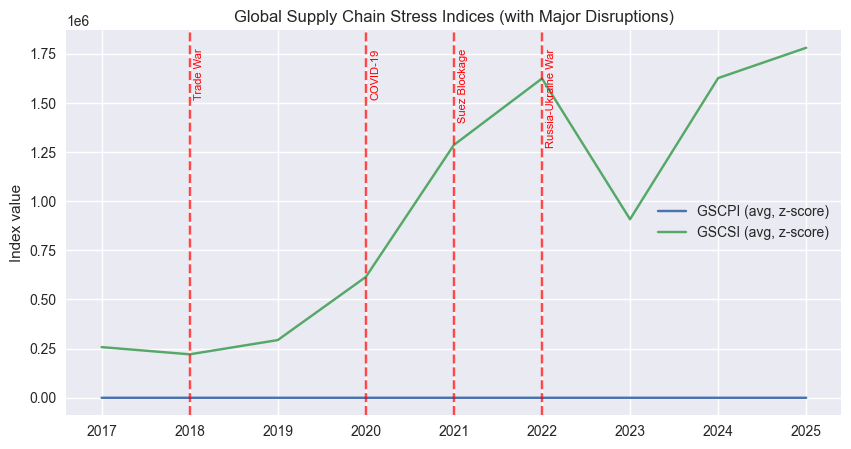

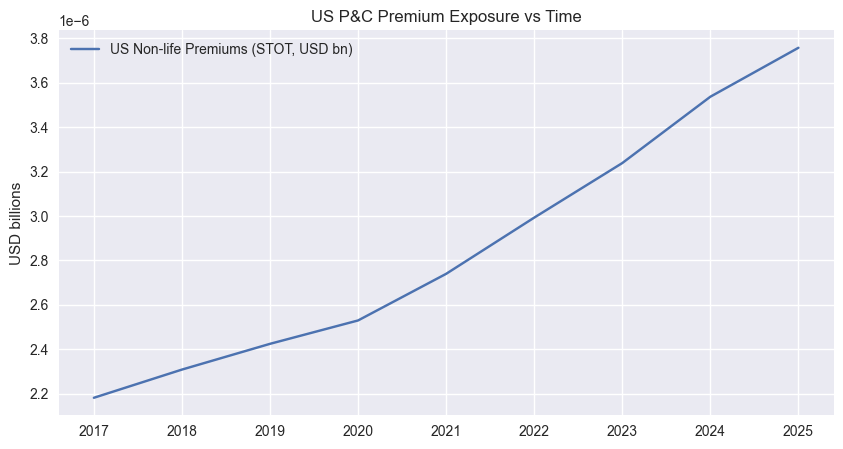

/var/folders/cj/fpg2r1gd3ys5xrg77691mvz00000gn/T/ipykernel_45278/3798931844.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.title(f"{title}\nSlope={model.params[1]:.3f}, p={model.pvalues[1]:.3f}")
/var/folders/cj/fpg2r1gd3ys5xrg77691mvz00000gn/T/ipykernel_45278/3798931844.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.title(f"{title}\nSlope={model.params[1]:.3f}, p={model.pvalues[1]:.3f}")


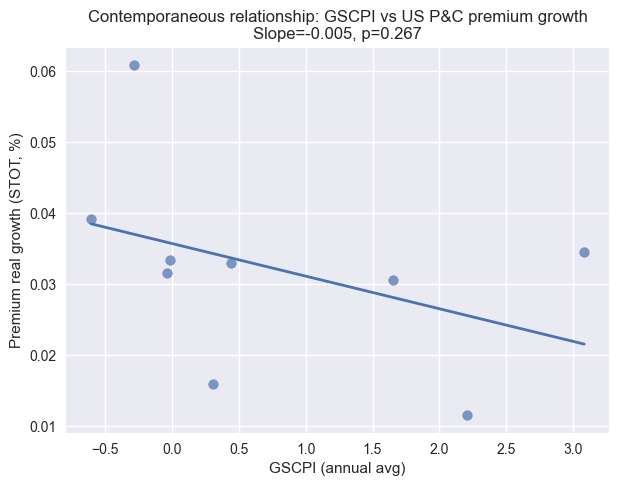

/var/folders/cj/fpg2r1gd3ys5xrg77691mvz00000gn/T/ipykernel_45278/3798931844.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.title(f"{title}\nSlope={model.params[1]:.3f}, p={model.pvalues[1]:.3f}")
/var/folders/cj/fpg2r1gd3ys5xrg77691mvz00000gn/T/ipykernel_45278/3798931844.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.title(f"{title}\nSlope={model.params[1]:.3f}, p={model.pvalues[1]:.3f}")


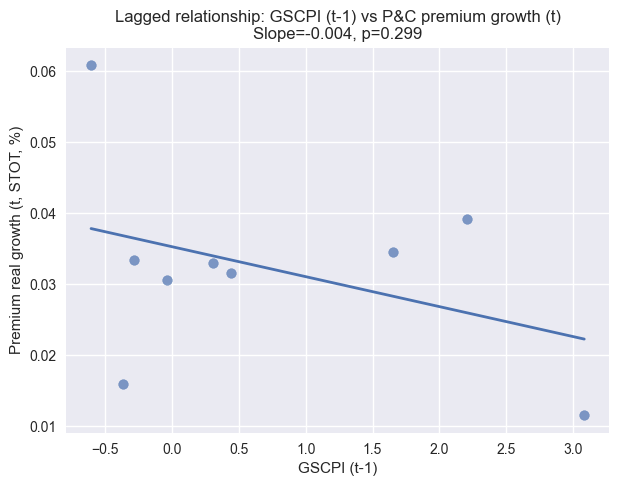

In [14]:

# ============================================
# 7. Exploratory plots
# ============================================

# 7.1 Time series: stress vs insurance exposure (example: STOT)
plt.figure(figsize=(10, 5))
plt.plot(df_model["Year"], df_model["GSCPI"], label="GSCPI (avg, z-score)")
plt.plot(df_model["Year"], df_model["GSCSI"], label="GSCSI (avg, z-score)")
# Key supply chain shock events (Year may be int or datetime)
events = {
    "Trade War": 2018,
    "COVID-19": 2020,
    "Suez Blockage": 2021,
    "Russia-Ukraine War": 2022
}

for label, year in events.items():
    plt.axvline(x=year, color="red", linestyle="--", alpha=0.7)
    plt.text(year + 0.05, plt.ylim()[1]*0.95, label, rotation=90,
             color="red", fontsize=8, va="top")

plt.ylabel("Index value")
plt.legend()
# plt.title("Global Supply Chain Stress Indices (Annual Average)")
plt.title("Global Supply Chain Stress Indices (with Major Disruptions)")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df_model["Year"], df_model["Premium_USD_STOT"] / 1e9, label="US Non-life Premiums (STOT, USD bn)")
plt.ylabel("USD billions")
plt.legend()
plt.title("US P&C Premium Exposure vs Time")
plt.show()

# 7.2 Scatter with regression line: stress vs premium growth
def scatter_with_reg(x, y, x_label, y_label, title):
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = model.predict(sm.add_constant(x_line))

    plt.figure(figsize=(7, 5))
    plt.scatter(x, y, alpha=0.7)
    plt.plot(x_line, y_line, lw=2)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(f"{title}\nSlope={model.params[1]:.3f}, p={model.pvalues[1]:.3f}")
    plt.show()
    return model

# Example: contemporaneous
scatter_with_reg(
    df_model["GSCPI"],
    df_model["PremiumRealGrowth_STOT"],
    "GSCPI (annual avg)",
    "Premium real growth (STOT, %)",
    "Contemporaneous relationship: GSCPI vs US P&C premium growth"
)

# Example: lagged stress -> next year's premium growth
scatter_with_reg(
    df_model["GSCPI_lag1"],
    df_model["PremiumRealGrowth_STOT"],
    "GSCPI (t-1)",
    "Premium real growth (t, STOT, %)",
    "Lagged relationship: GSCPI (t-1) vs P&C premium growth (t)"
)

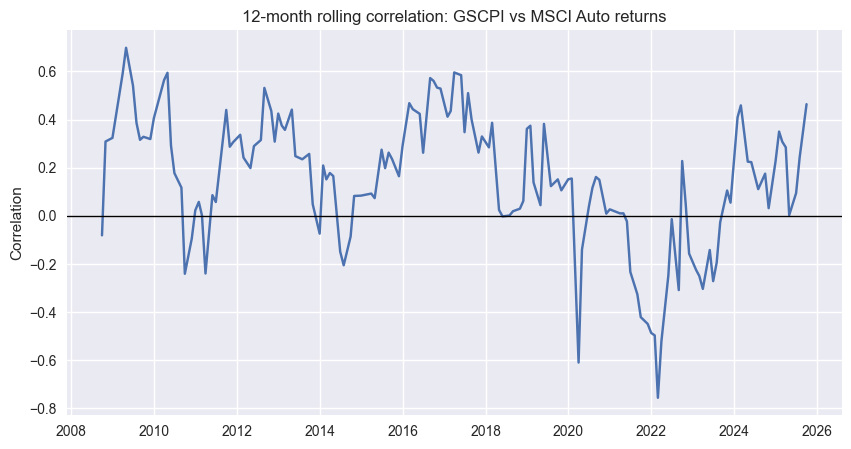

In [16]:

# ============================================
# 8. Rolling correlations (if you keep things monthly)
# ============================================
# If you decide to work at monthly frequency for part of the analysis,
# you can do something like this with GSCPI + a monthly proxy for risk:
#
#   - For example, use monthly MSCI sector returns as a "market-implied"
#     risk proxy for manufacturing-related firms.

# Example monthly pipeline (if you want it):
# (Assumes msci_auto + gscpi are both monthly.)

monthly = (
    gscpi[["Date", "GSCPI"]]
    .merge(msci_auto[["Date", "MSCI_Auto"]], on="Date", how="inner")
    .sort_values("Date")
    .copy()
)
monthly["MSCI_Auto_Return"] = monthly["MSCI_Auto"].pct_change() * 100

monthly["GSCPI_3m_roll"] = monthly["GSCPI"].rolling(3).mean()
monthly["Corr_12m"] = (
    monthly["GSCPI"].rolling(12).corr(monthly["MSCI_Auto_Return"])
)

plt.figure(figsize=(10, 5))
plt.plot(monthly["Date"], monthly["Corr_12m"])
plt.axhline(0, color="black", lw=1)
plt.title("12-month rolling correlation: GSCPI vs MSCI Auto returns")
plt.ylabel("Correlation")
plt.show()

In [13]:

# ============================================
# 9. Multivariate regression: supply chain stress & controls
# ============================================

# Example regression:
#   Dependent: P&C premium real growth (STOT)
#   Predictors: lagged GSCPI, lagged GSCSI, manufacturing cycle & PPI
reg_df = df_model.dropna(subset=[
    "PremiumRealGrowth_STOT",
    "GSCPI_lag1",
    "GSCSI_lag1",
    "IPMAN_YoY",
    "PPI_YoY"
]).copy()

X = reg_df[["GSCPI_lag1", "GSCSI_lag1", "IPMAN_YoY", "PPI_YoY"]]
X = sm.add_constant(X)
y = reg_df["PremiumRealGrowth_STOT"]

model_multi = sm.OLS(y, X).fit()
print(model_multi.summary())


                              OLS Regression Results                              
Dep. Variable:     PremiumRealGrowth_STOT   R-squared:                       0.399
Model:                                OLS   Adj. R-squared:                 -0.202
Method:                     Least Squares   F-statistic:                    0.6636
Date:                    Tue, 09 Dec 2025   Prob (F-statistic):              0.650
Time:                            13:56:11   Log-Likelihood:                 28.453
No. Observations:                       9   AIC:                            -46.91
Df Residuals:                           4   BIC:                            -45.92
Df Model:                               4                                         
Covariance Type:                nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  k, _ = kurtosistest(a, axis)
